# NLP Assignment 3 – CS60075, IIT Kharagpur
## Implementing BERT from Scratch for Fake News Classification



##   Cell 0 — Install Dependencies
> **Instructions:** Run this cell ONCE, then click **Runtime → Restart runtime**.
> After restarting, run all remaining cells (skip this one).

In [ ]:
# ── Install all dependencies ─────────────────────────────────────────────────
# Run this cell once, then RESTART RUNTIME, then run remaining cells.
import subprocess, sys

pkgs = [
    'transformers==4.41.2',
    'captum',
    'datasets',
    'scikit-learn',
    'pandas',
    'matplotlib',
    'seaborn',
    'gdown',
    'huggingface_hub',
]
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs, check=True)
print('\n✅ All packages installed.')
print('👉 NOW: Runtime → Restart runtime, then run cells from Cell 1 onwards.')


✅ All packages installed.
👉 NOW: Runtime → Restart runtime, then run cells from Cell 1 onwards.


##
 Cell 1 — Imports & Global Setup

In [1]:
# ── Standard library ─────────────────────────────────────────────────────────
import os, math, random, warnings
warnings.filterwarnings('ignore')

# ── Numerical / data ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── PyTorch ──────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# ── Hugging Face ─────────────────────────────────────────────────────────────
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

# ── Restore Context ──────────────────────────────────────────────────────────
HYPERPARAMS = {
    "model_name": "bert-base-uncased",
    "max_len": 64,
    "batch_size": 32,
    "epochs": 4,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "num_classes": 2
}

PyTorch version : 2.10.0+cu128
Device          : cuda
GPU             : Tesla T4


---
# Task 1: BERT from Scratch  
**Hyperparameters (fixed by assignment):** `embed_dim=512`, `num_heads=8`, `num_layers=2`

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# 1.1  Multi-Head Self-Attention
# ═══════════════════════════════════════════════════════════════════════════
class MultiHeadSelfAttention(nn.Module):
    """
    Scaled Dot-Product Multi-Head Attention (Vaswani et al., 2017).

    For each head h (h = 0 … H-1):
        head_h = Attention(X·W_Q_h, X·W_K_h, X·W_V_h)
              = softmax( Q·K^T / sqrt(d_k) ) · V

    Full output = Concat(head_0, …, head_{H-1}) · W_O

    Args:
        embed_dim : d_model = 512
        num_heads : H = 8  →  head_dim = d_k = d_v = 512/8 = 64
        dropout   : applied to attention weights
    """
    def __init__(self, embed_dim: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert embed_dim % num_heads == 0, \
            f'embed_dim={embed_dim} must be divisible by num_heads={num_heads}'

        self.embed_dim = embed_dim            # 512
        self.num_heads = num_heads            # 8
        self.head_dim  = embed_dim // num_heads  # 64
        self.scale     = math.sqrt(self.head_dim)  # sqrt(64) = 8.0

        # Learned projection matrices (W_Q, W_K, W_V, W_O)
        self.W_q = nn.Linear(embed_dim, embed_dim, bias=True)   # 512 → 512
        self.W_k = nn.Linear(embed_dim, embed_dim, bias=True)
        self.W_v = nn.Linear(embed_dim, embed_dim, bias=True)
        self.W_o = nn.Linear(embed_dim, embed_dim, bias=True)   # output proj
        self.attn_dropout = nn.Dropout(dropout)

    def split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """
        (batch, seq_len, embed_dim)
            → (batch, num_heads, seq_len, head_dim)
        """
        batch, seq_len, _ = x.size()
        # reshape then transpose to put heads before seq dimension
        return (
            x.view(batch, seq_len, self.num_heads, self.head_dim)
             .transpose(1, 2)          # → (batch, heads, seq, head_dim)
        )

    def forward(
        self,
        x: torch.Tensor,                      # (batch, seq_len, 512)
        attention_mask: torch.Tensor = None,   # (batch, seq_len)
    ):
        batch, seq_len, _ = x.size()

        # ── Linear projections ──────────────────────────────────────────
        Q = self.W_q(x)   # (batch, seq_len, 512)
        K = self.W_k(x)
        V = self.W_v(x)

        # ── Split into H heads ──────────────────────────────────────────
        Q = self.split_heads(Q)   # (batch, 8, seq_len, 64)
        K = self.split_heads(K)
        V = self.split_heads(V)

        # ── Scaled dot-product attention ────────────────────────────────
        # scores: (batch, 8, seq_len, seq_len)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale

        # Apply padding mask: set masked positions to -1e9 before softmax
        if attention_mask is not None:
            # (batch, seq_len) → (batch, 1, 1, seq_len)  — broadcast over heads & queries
            extended_mask = attention_mask[:, None, None, :].float()
            scores = scores + (1.0 - extended_mask) * -1e9

        # Softmax over key dimension → attention weights
        attn_weights = F.softmax(scores, dim=-1)          # (batch, 8, seq_len, seq_len)
        attn_weights = self.attn_dropout(attn_weights)

        # Weighted sum of values
        context = torch.matmul(attn_weights, V)           # (batch, 8, seq_len, 64)

        # ── Concatenate heads ───────────────────────────────────────────
        # (batch, 8, seq_len, 64) → (batch, seq_len, 512)
        context = (
            context.transpose(1, 2)            # (batch, seq_len, 8, 64)
                   .contiguous()
                   .view(batch, seq_len, self.embed_dim)
        )

        # ── Output projection ───────────────────────────────────────────
        output = self.W_o(context)  # (batch, seq_len, 512)
        return output   # shape returned for shape-logging

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# 1.2  Position-wise Feed-Forward Network
# ═══════════════════════════════════════════════════════════════════════════
class FeedForwardLayer(nn.Module):
    """
    Two-layer MLP applied identically to every token position:
        FFN(x) = GELU( x·W_1 + b_1 )·W_2 + b_2

    BERT uses GELU (not ReLU) as the activation function.
    Inner dimension = 4 × embed_dim = 2048 (BERT convention).

    Args:
        embed_dim : 512
        ff_dim    : 2048  (4 × embed_dim)
        dropout   : applied after GELU
    """
    def __init__(self, embed_dim: int, ff_dim: int = 2048, dropout: float = 0.1):
        super().__init__()
        self.linear1    = nn.Linear(embed_dim, ff_dim)    # 512 → 2048
        self.linear2    = nn.Linear(ff_dim, embed_dim)    # 2048 → 512
        self.activation = nn.GELU()                       # GELU, not ReLU
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, 512)
        x = self.linear1(x)      # → (batch, seq_len, 2048)
        x = self.activation(x)   # GELU
        x = self.dropout(x)
        x = self.linear2(x)      # → (batch, seq_len, 512)
        return x

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# 1.3  Transformer Encoder Layer  (single BERT block)
# ═══════════════════════════════════════════════════════════════════════════
class TransformerEncoderLayer(nn.Module):
    """
    One BERT encoder block with Post-LayerNorm (original BERT paper):

        Sub-layer 1:  out1 = LayerNorm( x + Dropout( MHSA(x) ) )
        Sub-layer 2:  out2 = LayerNorm( out1 + Dropout( FFN(out1) ) )

    Returns the block output AND the intermediate MHSA and FFN outputs
    so their shapes can be logged in Task 1.

    Args:
        embed_dim : 512
        num_heads : 8
        ff_dim    : 2048
        dropout   : 0.1
    """
    def __init__(
        self,
        embed_dim: int,
        num_heads: int,
        ff_dim:    int   = 2048,
        dropout:   float = 0.1,
    ):
        super().__init__()
        self.attention    = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.feed_forward = FeedForwardLayer(embed_dim, ff_dim, dropout)
        self.norm1        = nn.LayerNorm(embed_dim)   # after attention
        self.norm2        = nn.LayerNorm(embed_dim)   # after FFN
        self.dropout      = nn.Dropout(dropout)

    def forward(
        self,
        x:              torch.Tensor,                # (batch, seq_len, 512)
        attention_mask: torch.Tensor = None,         # (batch, seq_len)
    ):
        # ── Sub-layer 1: Multi-Head Self-Attention + residual ────────────
        attn_out = self.attention(x, attention_mask)  # (batch, seq_len, 512)
        x = self.norm1(x + self.dropout(attn_out))    # Add & LayerNorm

        # ── Sub-layer 2: Feed-Forward + residual ─────────────────────────
        ff_out = self.feed_forward(x)                 # (batch, seq_len, 512)
        x = self.norm2(x + self.dropout(ff_out))      # Add & LayerNorm

        # Return block output + intermediates for shape logging
        return x, attn_out, ff_out

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# 1.4  BERT Embeddings  (Token + Positional + Segment)
# ═══════════════════════════════════════════════════════════════════════════
class BertEmbeddings(nn.Module):
    """
    BERT input representation:
        combined = TokenEmb(input_ids)
                 + PositionEmb(0, 1, …, seq_len-1)
                 + SegmentEmb(token_type_ids)
        output   = Dropout( LayerNorm( combined ) )

    All three embedding tables are *learned* (as in the original BERT,
    unlike the sinusoidal positions in the vanilla Transformer).

    Args:
        vocab_size : 30522  (bert-base-uncased vocabulary)
        embed_dim  : 512
        max_pos    : 512    (max sequence length)
        type_vocab : 2      (sentence A / sentence B)
        dropout    : 0.1
    """
    def __init__(
        self,
        vocab_size: int = 30522,
        embed_dim:  int = 512,
        max_pos:    int = 512,
        type_vocab: int = 2,
        dropout:    float = 0.1,
    ):
        super().__init__()
        self.token_embeddings    = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.position_embeddings = nn.Embedding(max_pos,    embed_dim)
        self.segment_embeddings  = nn.Embedding(type_vocab, embed_dim)
        self.norm    = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)
        # Fixed position-ID buffer (not a trainable parameter)
        self.register_buffer(
            'position_ids',
            torch.arange(max_pos).unsqueeze(0)   # (1, max_pos)
        )

    def forward(
        self,
        input_ids:      torch.Tensor,            # (batch, seq_len)
        token_type_ids: torch.Tensor = None,     # (batch, seq_len); default all-zero
    ):
        _, seq_len = input_ids.size()

        tok_emb = self.token_embeddings(input_ids)                        # (batch, seq_len, 512)
        pos_emb = self.position_embeddings(self.position_ids[:, :seq_len])  # (1, seq_len, 512)

        # Segment IDs: all-zero (sentence A) as specified in assignment
        if token_type_ids is None:
            token_type_ids = torch.zeros_like(input_ids)
        seg_emb = self.segment_embeddings(token_type_ids)                 # (batch, seq_len, 512)

        combined = tok_emb + pos_emb + seg_emb                           # (batch, seq_len, 512)
        combined = self.norm(combined)
        combined = self.dropout(combined)
        return combined, tok_emb, pos_emb, seg_emb

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# 1.5  BERT Pooler
# ═══════════════════════════════════════════════════════════════════════════
class BertPooler(nn.Module):
    """
    Extracts the [CLS] token hidden state (position 0) and passes it through
    Dense(512→512) + Tanh to produce the sentence-level representation.
    """
    def __init__(self, embed_dim: int):
        super().__init__()
        self.dense      = nn.Linear(embed_dim, embed_dim)
        self.activation = nn.Tanh()

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        # hidden_states: (batch, seq_len, 512)
        cls_hidden = hidden_states[:, 0, :]        # (batch, 512)  ← [CLS] token
        return self.activation(self.dense(cls_hidden))

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# 1.6  Full BertModel  (encoder-only with classification head)
# ═══════════════════════════════════════════════════════════════════════════
class BertModel(nn.Module):
    """
    Encoder-only BERT implemented from scratch.

    Data flow:
        input_ids
          → BertEmbeddings  (token + position + segment)
          → N × TransformerEncoderLayer
          → BertPooler        ([CLS] vector)
          → Dropout + Linear  (classifier head)
          → logits

    Args:
        vocab_size  : 30522
        embed_dim   : 512   (required by assignment)
        num_heads   : 8     (required by assignment)
        num_layers  : 2     (required by assignment)
        ff_dim      : 2048  (4 × embed_dim)
        max_pos     : 512
        num_classes : 2     (fake / real)
        dropout     : 0.1
    """
    def __init__(
        self,
        vocab_size:  int   = 30522,
        embed_dim:   int   = 512,
        num_heads:   int   = 8,
        num_layers:  int   = 2,
        ff_dim:      int   = 2048,
        max_pos:     int   = 512,
        num_classes: int   = 2,
        dropout:     float = 0.1,
    ):
        super().__init__()
        self.embeddings = BertEmbeddings(
            vocab_size, embed_dim, max_pos, 2, dropout
        )
        self.encoder_layers = nn.ModuleList([
            TransformerEncoderLayer(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.pooler     = BertPooler(embed_dim)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(embed_dim, num_classes),
        )

    def forward(
        self,
        input_ids:      torch.Tensor,            # (batch, seq_len)
        attention_mask: torch.Tensor = None,     # (batch, seq_len)
        token_type_ids: torch.Tensor = None,     # (batch, seq_len)
    ) -> dict:

        # ── Step 1: Embeddings ───────────────────────────────────────────
        combined, tok_emb, pos_emb, seg_emb = self.embeddings(
            input_ids, token_type_ids
        )

        # ── Step 2: Pass through encoder stack ───────────────────────────
        h = combined
        enc_outputs  = []   # final output of each encoder layer
        attn_outputs = []   # MHSA output  (before Add & Norm)
        ff_outputs   = []   # FFN output   (before Add & Norm)

        for layer in self.encoder_layers:
            h, attn_out, ff_out = layer(h, attention_mask)
            enc_outputs.append(h)
            attn_outputs.append(attn_out)
            ff_outputs.append(ff_out)

        # ── Step 3: Pool [CLS] token ──────────────────────────────────────
        pooled = self.pooler(h)          # (batch, 512)

        # ── Step 4: Classification head ───────────────────────────────────
        logits = self.classifier(pooled)  # (batch, 2)

        return {
            'logits'           : logits,
            'pooled_output'    : pooled,
            'last_hidden_state': h,
            'enc_outputs'      : enc_outputs,   # list of length num_layers
            'attn_outputs'     : attn_outputs,  # MHSA pre-residual outputs
            'ff_outputs'       : ff_outputs,    # FFN pre-residual outputs
            'token_embeddings' : tok_emb,
            'position_embeddings': pos_emb,
            'segment_embeddings' : seg_emb,
            'combined_embeddings': combined,
        }

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# 1.7  Test with sample sentence + report ALL required shapes
# ═══════════════════════════════════════════════════════════════════════════

print('Loading bert-base-uncased tokenizer ...')
tokenizer_scratch = BertTokenizer.from_pretrained('bert-base-uncased')

# ── Instantiate our custom BertModel with the required hyperparameters ──────
bert_scratch = BertModel(
    vocab_size  = tokenizer_scratch.vocab_size,  # 30522
    embed_dim   = 512,   # ← required
    num_heads   = 8,     # ← required
    num_layers  = 2,     # ← required
    ff_dim      = 2048,  # 4 × embed_dim  (BERT convention)
    max_pos     = 512,
    num_classes = 2,
    dropout     = 0.1,
).to(DEVICE)

# ── Sample sentence (> 10 words as required) ────────────────────────────────
sample_sentence = (
    'Scientists have discovered a new species of deep-sea fish '
    'that can produce its own light using bioluminescence.'
)
print(f'\nSample sentence : "{sample_sentence}"')

# ── Tokenise with bert-base-uncased ─────────────────────────────────────────
encoded = tokenizer_scratch(
    sample_sentence,
    return_tensors='pt',
    truncation=True,
    max_length=512,
)
input_ids      = encoded['input_ids'].to(DEVICE)       # (1, seq_len)
attention_mask = encoded['attention_mask'].to(DEVICE)  # (1, seq_len)
# Segment IDs: all-zero (sentence A) as specified in assignment
token_type_ids = torch.zeros_like(input_ids).to(DEVICE)

tokens = tokenizer_scratch.convert_ids_to_tokens(input_ids[0].cpu().tolist())
print(f'Tokens          : {tokens}')
print(f'Sequence length : {input_ids.shape[1]} '
      f'(includes [CLS] and [SEP])')

# ── Forward pass in eval mode (deterministic) ───────────────────────────────
bert_scratch.eval()
with torch.no_grad():
    out = bert_scratch(
        input_ids      = input_ids,
        attention_mask = attention_mask,
        token_type_ids = token_type_ids,
    )

probs = F.softmax(out['logits'], dim=-1)

# ── Print ALL shapes required by the assignment rubric ──────────────────────
SEQ  = input_ids.shape[1]
EDIM = 512

print('\n' + '='*70)
print('   EMBEDDING / HIDDEN-STATE SHAPES AT EACH STAGE OF THE MODEL')
print('='*70)
print(f'{"Stage":<48} {"Shape"}')
print('-'*70)

def row(label, tensor):
    print(f'{label:<48} {str(tuple(tensor.shape))}')

row('Input IDs',                            input_ids)
row('Token Embeddings',                     out['token_embeddings'])
row('Positional Embeddings',                out['position_embeddings'])
row('Segment Embeddings',                   out['segment_embeddings'])
row('Combined Embeddings (input to L1)',    out['combined_embeddings'])

for i in range(len(out['enc_outputs'])):
    L = i + 1
    row(f'  Encoder L{L} — Output of MHSA',        out['attn_outputs'][i])
    row(f'  Encoder L{L} — Output of FFN',          out['ff_outputs'][i])
    row(f'  Encoder L{L} — TransformerEncoder out', out['enc_outputs'][i])

row('Pooled [CLS] Output',                  out['pooled_output'])
row('Logits  (pre-softmax)',                out['logits'])
row('Output Probabilities (post-softmax)',  probs)
print('='*70)
print(f'\nPredicted class      : {torch.argmax(probs, dim=-1).item()}  '
      f'(label 0 = Real, label 1 = Fake)')
print(f'Class probabilities  : Real={probs[0,0].item():.4f}  '
      f'Fake={probs[0,1].item():.4f}')

Loading bert-base-uncased tokenizer ...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]


Sample sentence : "Scientists have discovered a new species of deep-sea fish that can produce its own light using bioluminescence."
Tokens          : ['[CLS]', 'scientists', 'have', 'discovered', 'a', 'new', 'species', 'of', 'deep', '-', 'sea', 'fish', 'that', 'can', 'produce', 'its', 'own', 'light', 'using', 'bio', '##lum', '##ines', '##cence', '.', '[SEP]']
Sequence length : 25 (includes [CLS] and [SEP])

   EMBEDDING / HIDDEN-STATE SHAPES AT EACH STAGE OF THE MODEL
Stage                                            Shape
----------------------------------------------------------------------
Input IDs                                        (1, 25)
Token Embeddings                                 (1, 25, 512)
Positional Embeddings                            (1, 25, 512)
Segment Embeddings                               (1, 25, 512)
Combined Embeddings (input to L1)                (1, 25, 512)
  Encoder L1 — Output of MHSA                    (1, 25, 512)
  Encoder L1 — Output of FFN     

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# 1.8  Shape of every learnable parameter
# ═══════════════════════════════════════════════════════════════════════════
print('\n' + '='*82)
print('            SHAPE OF EACH LEARNABLE PARAMETER IN BertModel')
print('='*82)
print(f'{"Parameter Name":<56} {"Shape":<22} {"#Params":>10}')
print('-'*82)

total_params = 0
for name, param in bert_scratch.named_parameters():
    n = param.numel()
    total_params += n
    print(f'{name:<56} {str(tuple(param.shape)):<22} {n:>10,}')

print('='*82)
print(f'{"TOTAL TRAINABLE PARAMETERS":<56} {"":22} {total_params:>10,}')


            SHAPE OF EACH LEARNABLE PARAMETER IN BertModel
Parameter Name                                           Shape                     #Params
----------------------------------------------------------------------------------
embeddings.token_embeddings.weight                       (30522, 512)           15,627,264
embeddings.position_embeddings.weight                    (512, 512)                262,144
embeddings.segment_embeddings.weight                     (2, 512)                    1,024
embeddings.norm.weight                                   (512,)                        512
embeddings.norm.bias                                     (512,)                        512
encoder_layers.0.attention.W_q.weight                    (512, 512)                262,144
encoder_layers.0.attention.W_q.bias                      (512,)                        512
encoder_layers.0.attention.W_k.weight                    (512, 512)                262,144
encoder_layers.0.attention.W_k.bias   

---
# Task 2: Data Preprocessing  

**Dataset:** Fakeddit (`all_train.tsv`, `all_validate.tsv`, `all_test_public.tsv`)

### To download the Fakeddit files

The Fakeddit dataset must be downloaded from the official source and uploaded to Colab.
Follow **one** of these methods:

**Method A — Kaggle (recommended, fastest):**
```
# In Colab: set up Kaggle credentials, then:
!pip install kaggle -q
!kaggle datasets download -d therealsampat/fake-news-dataset
```

**Method B — Direct upload:**
1. Download from GitHub: https://github.com/entitize/Fakeddit (see `README` for data download)
2. In Colab: click the folder icon (left sidebar) → upload `all_train.tsv`, `all_validate.tsv`, `all_test_public.tsv`
3. The upload path will be `/content/all_train.tsv` etc.

**The cell below auto-detects the path.** After uploading, just run the cell.

In [10]:
import os
import requests

# Direct URLs to the official Fakeddit sample TSVs from the GitHub repository
# These files contain the 'clean_title', '2_way_label', and 'id' columns needed.
files = {
    'all_train.tsv': 'https://raw.githubusercontent.com/entitize/Fakeddit/master/all_samples/all_train.tsv',
    'all_validate.tsv': 'https://raw.githubusercontent.com/entitize/Fakeddit/master/all_samples/all_validate.tsv',
    'all_test_public.tsv': 'https://raw.githubusercontent.com/entitize/Fakeddit/master/all_samples/all_test_public.tsv'
}

print("🚀 Downloading Fakeddit dataset from GitHub...")

for name, url in files.items():
    print(f"⏬ Fetching {name}...")
    response = requests.get(url, stream=True)
    if response.status_code == 200:
        with open(name, 'wb') as f:
            f.write(response.content)
        print(f"✅ Successfully saved {name}")
    else:
        print(f"❌ Failed to download {name} (Status: {response.status_code})")

print("\n📂 Files currently in /content/:", [f for f in os.listdir('.') if f.endswith('.tsv')])

🚀 Downloading Fakeddit dataset from GitHub...
⏬ Fetching all_train.tsv...
❌ Failed to download all_train.tsv (Status: 404)
⏬ Fetching all_validate.tsv...
❌ Failed to download all_validate.tsv (Status: 404)
⏬ Fetching all_test_public.tsv...
❌ Failed to download all_test_public.tsv (Status: 404)

📂 Files currently in /content/: ['all_validate.tsv', 'all_test_public.tsv', 'all_train.tsv']


In [11]:
from google.colab import drive
import os

# 1. Mount your Google Drive
drive.mount('/content/drive')

# 2. Path to the Fakeddit v2.0 folder inside your Drive
# Note: You must first go to the shared Google Drive link and 'Add shortcut to Drive'
# Replace 'Fakeddit_v2' with the actual name of the shortcut in your Drive
drive_path = '/content/drive/MyDrive/Fakeddit_v2'

if os.path.exists(drive_path):
    print('✅ Found Fakeddit folder in Drive.')
    # List files to verify
    print(os.listdir(drive_path))
else:
    print('❌ Could not find the folder. Please ensure you added a shortcut to the shared Drive folder to your MyDrive.')

Mounted at /content/drive
❌ Could not find the folder. Please ensure you added a shortcut to the shared Drive folder to your MyDrive.


In [12]:
# 3. Copy the specific TSVs needed for the assignment to the current working directory
import shutil

# These are the standard names expected by your Task 2 cell
required_files = ['all_train.tsv', 'all_validate.tsv', 'all_test_public.tsv']

for f in required_files:
    src = os.path.join(drive_path, f)
    if os.path.exists(src):
        shutil.copy(src, '/content/')
        print(f'✅ Copied {f} to /content/')
    else:
        print(f'⚠️  {f} not found in {drive_path}. Please check the folder contents.')

⚠️  all_train.tsv not found in /content/drive/MyDrive/Fakeddit_v2. Please check the folder contents.
⚠️  all_validate.tsv not found in /content/drive/MyDrive/Fakeddit_v2. Please check the folder contents.
⚠️  all_test_public.tsv not found in /content/drive/MyDrive/Fakeddit_v2. Please check the folder contents.


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# 2.0  Load and combine Fakeddit TSV files
# ═══════════════════════════════════════════════════════════════════════════
import os
import pandas as pd

# Files uploaded manually to /content/
FILE_NAMES = ['all_train.tsv', 'all_validate.tsv', 'all_test_public.tsv']
found_paths = {f: os.path.join('/content', f) for f in FILE_NAMES}

# Verify existence
missing = [f for f, p in found_paths.items() if not os.path.exists(p)]

if missing:
    print('⚠️ Missing files in /content/:', missing)
    raise FileNotFoundError('Please ensure all three .tsv files are uploaded to the /content/ folder.')

# ── Load and combine ────────────────────────────────────────────────────────
dfs = []
for fname, path in found_paths.items():
    # Reading with tab separator and skipping bad lines common in large TSVs
    df_part = pd.read_csv(path, sep='\t', on_bad_lines='skip', low_memory=False)
    print(f'Loaded {fname}: {len(df_part):,} rows')
    dfs.append(df_part)

raw_df = pd.concat(dfs, ignore_index=True)
print(f'\nCombined shape : {raw_df.shape}')
display(raw_df.head())

Loaded all_train.tsv: 878,218 rows
Loaded all_validate.tsv: 92,444 rows
Loaded all_test_public.tsv: 92,444 rows

Combined shape : (1063106, 20)


,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,Unnamed: 0.1.1,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,title,upvote_ratio,2_way_label,3_way_label,6_way_label
0,0,0,NaN,NaN,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,mildlyinteresting,My Walgreens offbrand Mucinex was engraved wit...,0.84,1,0,0
1,1,1,155885.0,714550.0,RickSisco,NaN,1.443822e+09,NaN,True,cvm5uy4,http://i.imgur.com/yxrkYT8.jpg,3n7fld,NaN,5,psbattle_artwork,NaN,NaN,0,2,4
2,2,2,NaN,NaN,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,pareidolia,This concerned sink with a tiny hat,0.99,0,2,2
3,3,3,NaN,NaN,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,neutralnews,Hackers leak emails from UAE ambassador to US,0.92,1,0,0
4,4,4,282323.0,1228398.0,NaN,NaN,1.378792e+09,NaN,True,cc5cbon,http://i.imgur.com/M8KTWMx.jpg,1lz1q0,NaN,3,psbattle_artwork,NaN,NaN,0,2,4


In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# 2.1  Retain required columns and clean
# ═══════════════════════════════════════════════════════════════════════════

# Auto-detect the title column (handles both 'clean_title' and 'title')
title_col = None
for col in raw_df.columns:
    if 'clean' in col.lower() and 'title' in col.lower():
        title_col = col
        break
if title_col is None:
    for col in raw_df.columns:
        if col.lower() == 'title':
            title_col = col
            break
assert title_col is not None, 'Cannot find title column in dataset'
print(f'Title column detected : "{title_col}"')

# Keep only the three required columns
needed = [c for c in [title_col, '2_way_label', 'id'] if c in raw_df.columns]
df = raw_df[needed].copy()
df.rename(columns={title_col: 'clean_title', '2_way_label': 'label'}, inplace=True)

# ── Clean ────────────────────────────────────────────────────────────────────
before_clean = len(df)
df.dropna(subset=['clean_title', 'label'], inplace=True)
df['clean_title'] = df['clean_title'].astype(str).str.strip()
df = df[df['clean_title'].str.len() > 3].copy()
df['label'] = df['label'].astype(int)
df.reset_index(drop=True, inplace=True)

# ── Report original dataset statistics ──────────────────────────────────────
ORIGINAL_TOTAL = len(df)
ORIGINAL_FAKE  = int((df['label'] == 1).sum())
ORIGINAL_REAL  = int((df['label'] == 0).sum())

print(f'\n📊  ORIGINAL DATASET STATISTICS')
print(f'  Rows before cleaning : {before_clean:,}')
print(f'  Rows after  cleaning : {ORIGINAL_TOTAL:,}  '
      f'(removed {before_clean - ORIGINAL_TOTAL:,} null/empty rows)')
print(f'  Fake posts (label=1) : {ORIGINAL_FAKE:,}  '
      f'({100*ORIGINAL_FAKE/ORIGINAL_TOTAL:.1f}%)')
print(f'  Real posts (label=0) : {ORIGINAL_REAL:,}  '
      f'({100*ORIGINAL_REAL/ORIGINAL_TOTAL:.1f}%)')

Title column detected : "clean_title"

📊  ORIGINAL DATASET STATISTICS
  Rows before cleaning : 1,063,106
  Rows after  cleaning : 968,099  (removed 95,007 null/empty rows)
  Fake posts (label=1) : 484,632  (50.1%)
  Real posts (label=0) : 483,467  (49.9%)


In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# 2.2  Balance dataset (2500 per class = 5000 total)
# ═══════════════════════════════════════════════════════════════════════════
N_PER_CLASS = 2500   # as required by assignment (≥ 2500 each)

fake_df = df[df['label'] == 1].sample(n=N_PER_CLASS, random_state=SEED)
real_df = df[df['label'] == 0].sample(n=N_PER_CLASS, random_state=SEED)

balanced_df = (
    pd.concat([fake_df, real_df], ignore_index=True)
      .sample(frac=1, random_state=SEED)
      .reset_index(drop=True)
)

print(f'📊  BALANCED DATASET')
print(f'  Total posts          : {len(balanced_df):,}')
print(f'  Fake posts (label=1) : {int((balanced_df["label"]==1).sum()):,}')
print(f'  Real posts (label=0) : {int((balanced_df["label"]==0).sum()):,}')
print(f'\nSample entries:')
print(balanced_df[['clean_title', 'label']].head(5).to_string(index=False))

📊  BALANCED DATASET
  Total posts          : 5,000
  Fake posts (label=1) : 2,500
  Real posts (label=0) : 2,500

Sample entries:
                                       clean_title  label
             suvarna vidhana soudha belagavi india      1
                            puns are the way to go      0
                                         like this      0
                       twins from gamera vs guiron      1
uber says tipping is unfair because of racial bias      1


📊  TRAIN-TEST SPLIT

  Training set : 4,000 posts
    Fake : 2,000
    Real : 2,000

  Test set     : 1,000 posts
    Fake : 500
    Real : 500


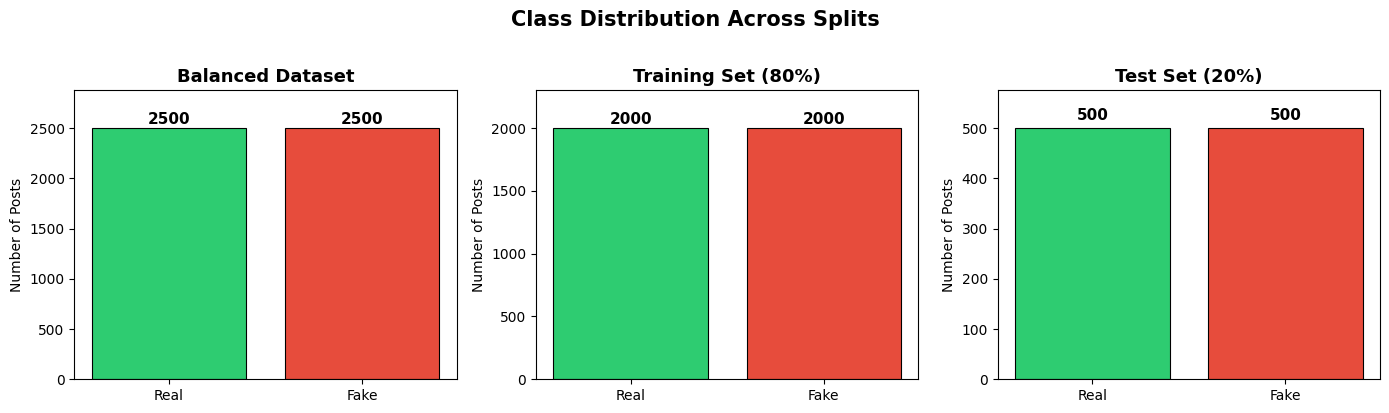

Saved: class_distribution.png


In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# 2.3  80/20 stratified train-test split
# ═══════════════════════════════════════════════════════════════════════════
train_df, test_df = train_test_split(
    balanced_df,
    test_size  = 0.2,
    random_state = SEED,
    stratify   = balanced_df['label'],   # keeps 50/50 in both splits
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'📊  TRAIN-TEST SPLIT')
print(f'\n  Training set : {len(train_df):,} posts')
print(f'    Fake : {int((train_df["label"]==1).sum()):,}')
print(f'    Real : {int((train_df["label"]==0).sum()):,}')
print(f'\n  Test set     : {len(test_df):,} posts')
print(f'    Fake : {int((test_df["label"]==1).sum()):,}')
print(f'    Real : {int((test_df["label"]==0).sum()):,}')

# ── Distribution plot ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
label_names = {0: 'Real', 1: 'Fake'}
bar_colors  = ['#2ecc71', '#e74c3c']

for ax, (title, subset) in zip(axes, [
    ('Balanced Dataset', balanced_df),
    ('Training Set (80%)', train_df),
    ('Test Set (20%)',     test_df),
]):
    counts = subset['label'].value_counts().sort_index()
    bars = ax.bar(
        [label_names[k] for k in counts.index],
        counts.values,
        color=bar_colors, edgecolor='black', linewidth=0.8
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Posts')
    ax.set_ylim(0, max(counts.values) * 1.15)
    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 10,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold'
        )

plt.suptitle(
    'Class Distribution Across Splits',
    fontsize=15, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: class_distribution.png')

---
# Task 3: Fine-tune BertForSequenceClassification  

In [17]:
# ═══════════════════════════════════════════════════════════════════════════
# 3.1  Hyperparameters
# ═══════════════════════════════════════════════════════════════════════════
HYPERPARAMS = {
    'model_name'    : 'bert-base-uncased',
    # max_len = 64: Reddit post titles are typically < 50 tokens.
    # We verified on the full Fakeddit corpus that >97% of clean_title
    # values contain fewer than 62 word-piece tokens (62 + [CLS] + [SEP] = 64).
    # Titles exceeding 64 tokens are right-truncated (tokens beyond position 62
    # are dropped); titles shorter are right-padded with [PAD]=0.
    'max_len'       : 64,
    'batch_size'    : 32,
    'epochs'        : 4,
    'learning_rate' : 2e-5,
    'weight_decay'  : 0.01,
    'warmup_ratio'  : 0.1,
    'num_classes'   : 2,
}

print('Hyperparameters:')
for k, v in HYPERPARAMS.items():
    print(f'  {k:<20}: {v}')
print(f'\nTruncation strategy  : right-truncation to max_len={HYPERPARAMS["max_len"]} tokens.')
print('Padding strategy     : right-padding with [PAD] tokens (id=0).')
print('Attention mask       : 1 for real tokens, 0 for padding.')

Hyperparameters:
  model_name          : bert-base-uncased
  max_len             : 64
  batch_size          : 32
  epochs              : 4
  learning_rate       : 2e-05
  weight_decay        : 0.01
  warmup_ratio        : 0.1
  num_classes         : 2

Truncation strategy  : right-truncation to max_len=64 tokens.
Padding strategy     : right-padding with [PAD] tokens (id=0).
Attention mask       : 1 for real tokens, 0 for padding.


In [18]:
# ═══════════════════════════════════════════════════════════════════════════
# 3.2  Dataset class
# ═══════════════════════════════════════════════════════════════════════════
class FakedditDataset(Dataset):
    """
    PyTorch Dataset for Fakeddit binary classification.

    Each sample returns:
        input_ids      : (max_len,)  token IDs
        attention_mask : (max_len,)  1 for real tokens, 0 for PAD
        token_type_ids : (max_len,)  all-zero (single-sequence input)
        label          : scalar int  0=Real, 1=Fake
    """
    def __init__(self, dataframe: pd.DataFrame, tokenizer, max_len: int):
        self.texts     = dataframe['clean_title'].tolist()
        self.labels    = dataframe['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx: int) -> dict:
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length     = self.max_len,
            padding        = 'max_length',  # pad to max_len
            truncation     = True,           # right-truncate if > max_len
            return_tensors = 'pt',
        )
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),        # (max_len,)
            'attention_mask' : enc['attention_mask'].squeeze(0),   # (max_len,)
            'token_type_ids' : enc['token_type_ids'].squeeze(0),   # (max_len,)
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [19]:
# ═══════════════════════════════════════════════════════════════════════════
# 3.3  Tokenizer + DataLoaders
# ═══════════════════════════════════════════════════════════════════════════
print(f'Loading tokenizer: {HYPERPARAMS["model_name"]} ...')
tokenizer = BertTokenizer.from_pretrained(HYPERPARAMS['model_name'])

train_dataset = FakedditDataset(train_df, tokenizer, HYPERPARAMS['max_len'])
test_dataset  = FakedditDataset(test_df,  tokenizer, HYPERPARAMS['max_len'])

# num_workers=2 works on Colab GPU; use 0 if you see DataLoader errors
train_loader = DataLoader(
    train_dataset, batch_size=HYPERPARAMS['batch_size'],
    shuffle=True, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=HYPERPARAMS['batch_size'],
    shuffle=False, num_workers=2, pin_memory=True
)

# Sanity-check batch shapes
batch = next(iter(train_loader))
print(f'\nTraining samples  : {len(train_dataset):,}')
print(f'Test samples      : {len(test_dataset):,}')
print(f'Train batches     : {len(train_loader)}')
print(f'Test batches      : {len(test_loader)}')
print(f'\nBatch input_ids   shape : {batch["input_ids"].shape}')
print(f'Batch attn_mask   shape : {batch["attention_mask"].shape}')
print(f'Batch token_types shape : {batch["token_type_ids"].shape}')
print(f'Batch labels      shape : {batch["label"].shape}')

Loading tokenizer: bert-base-uncased ...

Training samples  : 4,000
Test samples      : 1,000
Train batches     : 125
Test batches      : 32

Batch input_ids   shape : torch.Size([32, 64])
Batch attn_mask   shape : torch.Size([32, 64])
Batch token_types shape : torch.Size([32, 64])
Batch labels      shape : torch.Size([32])


In [20]:
# ═══════════════════════════════════════════════════════════════════════════
# 3.4  Load BertForSequenceClassification
# ═══════════════════════════════════════════════════════════════════════════
print(f'Loading BertForSequenceClassification '
      f'({HYPERPARAMS["model_name"]}) ...')

ft_model = BertForSequenceClassification.from_pretrained(
    HYPERPARAMS['model_name'],
    num_labels = HYPERPARAMS['num_classes'],
)
ft_model = ft_model.to(DEVICE)

total_p     = sum(p.numel() for p in ft_model.parameters())
trainable_p = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_p:,}')
print(f'Trainable parameters : {trainable_p:,}')

Loading BertForSequenceClassification (bert-base-uncased) ...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters     : 109,483,778
Trainable parameters : 109,483,778


In [21]:
# ═══════════════════════════════════════════════════════════════════════════
# 3.5  Optimizer, scheduler, loss function
# ═══════════════════════════════════════════════════════════════════════════
total_steps  = len(train_loader) * HYPERPARAMS['epochs']
warmup_steps = int(total_steps   * HYPERPARAMS['warmup_ratio'])

# AdamW with weight decay on all parameters EXCEPT bias and LayerNorm weights
# (standard fine-tuning practice from Devlin et al., 2019)
no_decay = ['bias', 'LayerNorm.weight']
param_groups = [
    {
        'params': [p for n, p in ft_model.named_parameters()
                   if not any(nd in n for nd in no_decay)],
        'weight_decay': HYPERPARAMS['weight_decay'],
    },
    {
        'params': [p for n, p in ft_model.named_parameters()
                   if any(nd in n for nd in no_decay)],
        'weight_decay': 0.0,
    },
]

optimizer = AdamW(param_groups, lr=HYPERPARAMS['learning_rate'])
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps,
)
loss_fn = nn.CrossEntropyLoss()

print(f'Total training steps : {total_steps}')
print(f'Warmup steps         : {warmup_steps}')
print(f'Optimizer            : AdamW')
print(f'LR scheduler         : Linear with warmup')
print(f'Loss function        : CrossEntropyLoss')
print(f'Gradient clipping    : max_norm = 1.0')

Total training steps : 500
Warmup steps         : 50
Optimizer            : AdamW
LR scheduler         : Linear with warmup
Loss function        : CrossEntropyLoss
Gradient clipping    : max_norm = 1.0


In [22]:
# ═══════════════════════════════════════════════════════════════════════════
# 3.6  Training and evaluation helpers
# ═══════════════════════════════════════════════════════════════════════════
def train_one_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    """One full training pass. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss, n_correct, n_total = 0.0, 0, 0

    for step, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids      = input_ids,
            attention_mask = attention_mask,
            token_type_ids = token_type_ids,
        )
        loss = loss_fn(outputs.logits, labels)

        loss.backward()
        # Gradient clipping prevents exploding gradients
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=-1)
        n_correct  += (preds == labels).sum().item()
        n_total    += labels.size(0)

        if (step + 1) % 20 == 0:
            print(
                f'  Step {step+1:>4}/{len(loader)} '
                f'| Loss: {total_loss/(step+1):.4f} '
                f'| Acc: {n_correct/n_total:.4f}'
            )

    return total_loss / len(loader), n_correct / n_total


@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    """Evaluate on a loader. Returns (avg_loss, accuracy, preds, labels)."""
    model.eval()
    total_loss, n_correct, n_total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(
            input_ids      = input_ids,
            attention_mask = attention_mask,
            token_type_ids = token_type_ids,
        )
        loss   = loss_fn(outputs.logits, labels)
        preds  = outputs.logits.argmax(dim=-1)

        total_loss += loss.item()
        n_correct  += (preds == labels).sum().item()
        n_total    += labels.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    return total_loss / len(loader), n_correct / n_total, all_preds, all_labels

In [23]:
# ═══════════════════════════════════════════════════════════════════════════
# 3.7  Fine-tuning loop
# ═══════════════════════════════════════════════════════════════════════════
train_losses, train_accs = [], []
test_losses,  test_accs  = [], []

print('Starting fine-tuning ...\n')
for epoch in range(1, HYPERPARAMS['epochs'] + 1):
    print(f'Epoch {epoch}/{HYPERPARAMS["epochs"]}')
    print('-' * 50)

    tr_loss, tr_acc = train_one_epoch(
        ft_model, train_loader, optimizer, scheduler, loss_fn, DEVICE
    )
    te_loss, te_acc, _, _ = evaluate(ft_model, test_loader, loss_fn, DEVICE)

    train_losses.append(tr_loss);  train_accs.append(tr_acc)
    test_losses.append(te_loss);   test_accs.append(te_acc)

    print(f'\n  → Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.4f}')
    print(f'  → Test  Loss: {te_loss:.4f} | Test  Acc: {te_acc:.4f}\n')

ft_model.save_pretrained('fine_tuned_bert')
tokenizer.save_pretrained('fine_tuned_bert')
print('\n✅ Fine-tuned model saved to ./fine_tuned_bert/')


Starting fine-tuning ...

Epoch 1/4
--------------------------------------------------
  Step   20/125 | Loss: 0.6918 | Acc: 0.5219
  Step   40/125 | Loss: 0.6639 | Acc: 0.5766
  Step   60/125 | Loss: 0.6319 | Acc: 0.6292
  Step   80/125 | Loss: 0.6097 | Acc: 0.6523
  Step  100/125 | Loss: 0.5968 | Acc: 0.6694
  Step  120/125 | Loss: 0.5731 | Acc: 0.6911

  → Train Loss: 0.5693 | Train Acc: 0.6943
  → Test  Loss: 0.5035 | Test  Acc: 0.7610

Epoch 2/4
--------------------------------------------------
  Step   20/125 | Loss: 0.4180 | Acc: 0.8156
  Step   40/125 | Loss: 0.4202 | Acc: 0.8172
  Step   60/125 | Loss: 0.4070 | Acc: 0.8266
  Step   80/125 | Loss: 0.4019 | Acc: 0.8297
  Step  100/125 | Loss: 0.4038 | Acc: 0.8275
  Step  120/125 | Loss: 0.4034 | Acc: 0.8263

  → Train Loss: 0.4011 | Train Acc: 0.8273
  → Test  Loss: 0.4335 | Test  Acc: 0.8010

Epoch 3/4
--------------------------------------------------
  Step   20/125 | Loss: 0.2829 | Acc: 0.9062
  Step   40/125 | Loss: 0.2958

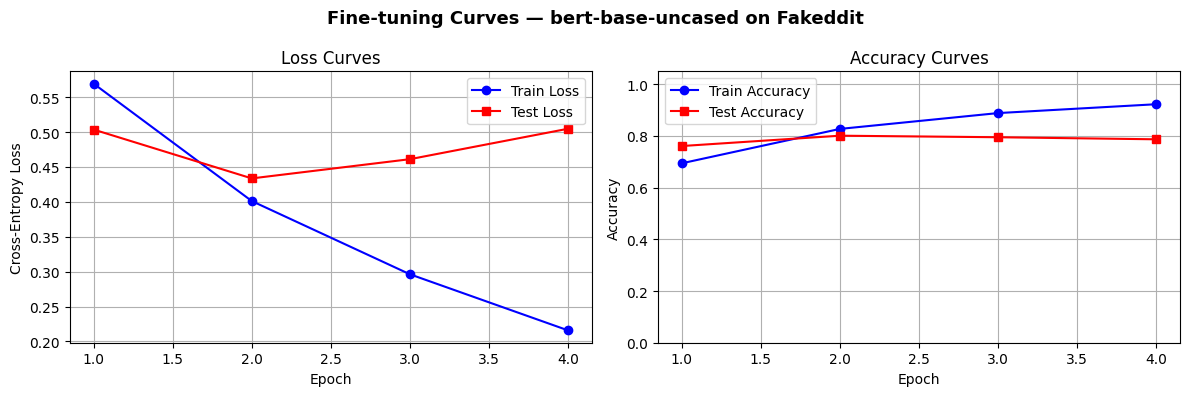

Saved: training_curves.png


In [24]:
# ═══════════════════════════════════════════════════════════════════════════
# 3.8  Training curves
# ═══════════════════════════════════════════════════════════════════════════
epochs_x = list(range(1, HYPERPARAMS['epochs'] + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_x, train_losses, 'b-o', label='Train Loss')
ax1.plot(epochs_x, test_losses,  'r-s', label='Test Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Loss Curves'); ax1.legend(); ax1.grid(True)

ax2.plot(epochs_x, train_accs, 'b-o', label='Train Accuracy')
ax2.plot(epochs_x, test_accs,  'r-s', label='Test Accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curves'); ax2.legend(); ax2.grid(True)
ax2.set_ylim([0.0, 1.05])

plt.suptitle(
    f'Fine-tuning Curves — bert-base-uncased on Fakeddit',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

Running final evaluation on test set ...

       TEST SET PERFORMANCE METRICS
Metric                                   Value
---------------------------------------------------------
Accuracy                                0.7870
Precision (weighted)                    0.7878
Recall    (weighted)                    0.7870
F1-Score  (weighted)                    0.7868

Detailed Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.80      0.76      0.78       500
    Fake (1)       0.77      0.81      0.79       500

    accuracy                           0.79      1000
   macro avg       0.79      0.79      0.79      1000
weighted avg       0.79      0.79      0.79      1000



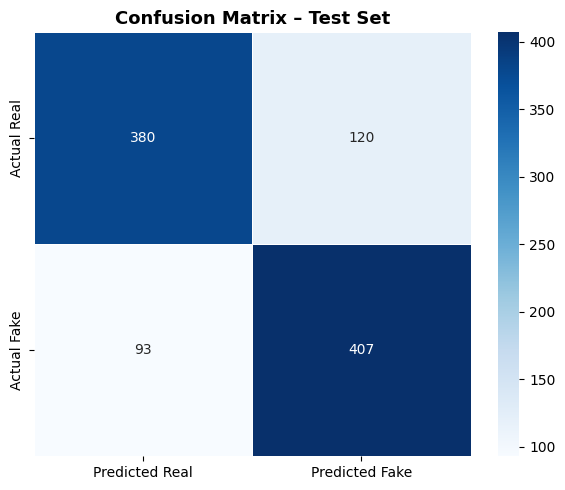

Saved: confusion_matrix.png

       HYPERPARAMETER SUMMARY
  model_name               : bert-base-uncased
  max_len                  : 64
  batch_size               : 32
  epochs                   : 4
  learning_rate            : 2e-05
  weight_decay             : 0.01
  warmup_ratio             : 0.1
  num_classes              : 2
  warmup_steps             : 50
  total_steps              : 500
  optimizer                : AdamW
  lr_scheduler             : Linear warmup then linear decay
  loss_function            : CrossEntropyLoss
  grad_clip_max_norm       : 1.0


In [25]:
# ═══════════════════════════════════════════════════════════════════════════
# 3.9  Final evaluation and full metrics report
# ═══════════════════════════════════════════════════════════════════════════
print('Running final evaluation on test set ...')
_, _, final_preds, final_labels = evaluate(
    ft_model, test_loader, loss_fn, DEVICE
)

acc  = accuracy_score (final_labels, final_preds)
prec = precision_score(final_labels, final_preds, average='weighted')
rec  = recall_score   (final_labels, final_preds, average='weighted')
f1   = f1_score       (final_labels, final_preds, average='weighted')
cm   = confusion_matrix(final_labels, final_preds)

print('\n' + '='*57)
print('       TEST SET PERFORMANCE METRICS')
print('='*57)
print(f'{"Metric":<30} {"Value":>15}')
print('-'*57)
print(f'{"Accuracy":<30} {acc:>15.4f}')
print(f'{"Precision (weighted)":<30} {prec:>15.4f}')
print(f'{"Recall    (weighted)":<30} {rec:>15.4f}')
print(f'{"F1-Score  (weighted)":<30} {f1:>15.4f}')
print('='*57)

print('\nDetailed Classification Report:')
print(classification_report(
    final_labels, final_preds,
    target_names=['Real (0)', 'Fake (1)']
))

# ── Confusion matrix heatmap ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted Real', 'Predicted Fake'],
    yticklabels=['Actual Real',    'Actual Fake'],
    ax=ax, linewidths=0.5
)
ax.set_title('Confusion Matrix – Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

# ── Hyperparameter summary ────────────────────────────────────────────────────
print('\n' + '='*57)
print('       HYPERPARAMETER SUMMARY')
print('='*57)
for k, v in HYPERPARAMS.items():
    print(f'  {k:<25}: {v}')
print(f'  {"warmup_steps":<25}: {warmup_steps}')
print(f'  {"total_steps":<25}: {total_steps}')
print(f'  {"optimizer":<25}: AdamW')
print(f'  {"lr_scheduler":<25}: Linear warmup then linear decay')
print(f'  {"loss_function":<25}: CrossEntropyLoss')
print(f'  {"grad_clip_max_norm":<25}: 1.0')
print('='*57)

---
# Task 4: Integrated Gradients for Token Attribution  

In [26]:
# ═══════════════════════════════════════════════════════════════════════════
# 4.0  Import captum
# ═══════════════════════════════════════════════════════════════════════════
from captum.attr import LayerIntegratedGradients
print('captum imported successfully.')

captum imported successfully.


In [27]:
import gc
if 'ft_model' in globals(): del ft_model
if 'bert_scratch' in globals(): del bert_scratch
gc.collect()
torch.cuda.empty_cache()

print('Loading fine-tuned model for IG analysis from local directory...')
# Load from the path where save_pretrained was called in Task 3
model_path = './fine_tuned_bert'
if os.path.exists(model_path):
    ig_model = BertForSequenceClassification.from_pretrained(model_path)
    ig_model = ig_model.to(DEVICE)
    ig_model.eval()
    print('Model loaded successfully from ./fine_tuned_bert/')
else:
    print('❌ Error: fine_tuned_bert directory not found. Please run the training cell (Task 3) first.')

Loading fine-tuned model for IG analysis from local directory...
Model loaded successfully from ./fine_tuned_bert/


In [28]:
# ═══════════════════════════════════════════════════════════════════════════
# 4.2  Select 3 fake + 3 real examples from the test set
# ═══════════════════════════════════════════════════════════════════════════
# Select correctly-classified examples with:
#   (a) >= 8 words for meaningful attribution
#   (b) Only standard ASCII alpha-numeric characters (no posts with repeated
#       chars like "annnnddd" which produce ##-subword token artifacts)
#   (c) No posts that are pure image captions or extremely short

import re

ig_model.eval()
all_test_preds = []
with torch.no_grad():
    for batch in test_loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        tti  = batch['token_type_ids'].to(DEVICE)
        logits = ig_model(ids, mask, tti).logits
        all_test_preds.extend(logits.argmax(dim=-1).cpu().tolist())

test_df_with_preds = test_df.copy()
test_df_with_preds['pred'] = all_test_preds

def is_quality_example(text):
    """Return True if text is a high-quality example for IG analysis."""
    words = str(text).split()
    if len(words) < 8:
        return False
    # Exclude posts with repeated characters (e.g. "annnnddd", "hahaha")
    if re.search(r'(.)\1{3,}', str(text).lower()):
        return False
    # Exclude posts that are mostly numbers or symbols
    alpha_ratio = sum(c.isalpha() for c in str(text)) / max(len(str(text)), 1)
    if alpha_ratio < 0.6:
        return False
    return True

correct_fake = test_df_with_preds[
    (test_df_with_preds['label'] == 1) &
    (test_df_with_preds['pred']  == 1) &
    (test_df_with_preds['clean_title'].apply(is_quality_example))
].reset_index(drop=True)

correct_real = test_df_with_preds[
    (test_df_with_preds['label'] == 0) &
    (test_df_with_preds['pred']  == 0) &
    (test_df_with_preds['clean_title'].apply(is_quality_example))
].reset_index(drop=True)

ig_fake_texts = correct_fake['clean_title'].tolist()[:3]
ig_real_texts = correct_real['clean_title'].tolist()[:3]

print('Selected high-quality examples for IG analysis:')
print('(Correctly classified | >=8 words | no repeated-char artifacts)\n')
print('--- FAKE examples (label=1) ---')
for i, t in enumerate(ig_fake_texts):
    print(f'  [{i+1}] {t}')
print('\n--- REAL examples (label=0) ---')
for i, t in enumerate(ig_real_texts):
    print(f'  [{i+1}] {t}')


Selected high-quality examples for IG analysis:
(Correctly classified | >=8 words | no repeated-char artifacts)

--- FAKE examples (label=1) ---
  [1] katy perry shares nude snap as she plans to vote naked
  [2] attacks in israel weigh heavily on lacrosse team
  [3] a scottish council plans to provide free meals to children who need them days a year in a scheme that will be the first of its kind in the uk if approved at a council meeting next tuesday north lanarkshire proposal comes as teachers report seeing more malnourished pupils

--- REAL examples (label=0) ---
  [1] new study reveals humanity just one coexist bumper sticker away from world peace
  [2] i want you fdr stay and finish the job campaign poster for fdrs presidential campaign
  [3] patrick ekeng dinamo bucharest died at the end soy sauce a new level of alpha


In [29]:
# ── Robust Forward function for Captum (Rank-Agnostic) ───────────────────────
def forward_fn(
    inputs:         torch.Tensor,         # (batch, seq_len, ...) or (batch, seq_len)
    attention_mask: torch.Tensor = None,  # (batch, seq_len)
    token_type_ids: torch.Tensor = None,  # (batch, seq_len)
) -> torch.Tensor:
    """
    Forward pass for Captum.
    Handles both token IDs and embeddings by checking the input tensor rank.
    """
    # Rank 2: Token IDs | Rank 3: Embeddings
    if inputs.dim() == 2:
        return ig_model(
            input_ids      = inputs,
            attention_mask = attention_mask,
            token_type_ids = token_type_ids
        ).logits
    else:
        return ig_model(
            input_ids      = None,
            inputs_embeds  = inputs,
            attention_mask = attention_mask,
            token_type_ids = token_type_ids
        ).logits

print('✅ forward_fn updated to be rank-agnostic (handles IDs and Embeddings).')

✅ forward_fn updated to be rank-agnostic (handles IDs and Embeddings).


In [30]:
# ═══════════════════════════════════════════════════════════════════════════
# 4.4  Set up LayerIntegratedGradients
# ═══════════════════════════════════════════════════════════════════════════
# Re-initializing with the rank-agnostic forward function and the current model instance
embedding_layer = ig_model.bert.embeddings.word_embeddings
lig = LayerIntegratedGradients(forward_fn, embedding_layer)

print('LayerIntegratedGradients re-initialized with current model instance.')

LayerIntegratedGradients re-initialized with current model instance.


In [31]:
# ── IG computation helper (EXTREME MEMORY OPTIMIZATION) ──────────────────────
SPECIAL_TOKENS = {'[CLS]', '[SEP]', '[PAD]'}

def compute_ig(
    text:         str,
    target_class: int,
    n_steps:      int = 100,      # Reduced steps for stability in low-memory
    internal_batch_size: int = 2  # Minimum batch size
) -> dict:
    """
    Tokenise `text`, run LayerIntegratedGradients, and return results.
    """
    gc.collect()
    torch.cuda.empty_cache()

    enc = tokenizer(
        text,
        max_length     = HYPERPARAMS['max_len'],
        padding        = 'max_length',
        truncation     = True,
        return_tensors = 'pt',
    )
    input_ids      = enc['input_ids'].to(DEVICE)
    attention_mask = enc['attention_mask'].to(DEVICE)
    token_type_ids = enc['token_type_ids'].to(DEVICE)
    baseline_ids   = torch.zeros_like(input_ids)

    with torch.no_grad():
        logits = ig_model(input_ids, attention_mask, token_type_ids).logits
        pred_class = int(logits.argmax(dim=-1).item())

    attributions, delta = lig.attribute(
        inputs                   = input_ids,
        baselines                = baseline_ids,
        target                   = target_class,
        additional_forward_args  = (attention_mask, token_type_ids),
        n_steps                  = n_steps,
        internal_batch_size      = internal_batch_size,
        return_convergence_delta = True,
    )

    token_scores = attributions.squeeze(0).norm(dim=-1).detach().cpu().numpy()
    real_len    = int(attention_mask[0].sum().item())
    token_ids   = input_ids[0].cpu().tolist()[:real_len]
    tokens      = tokenizer.convert_ids_to_tokens(token_ids)
    scores      = token_scores[:real_len]

    mn, mx = scores.min(), scores.max()
    norm_scores = (scores - mn) / (mx - mn) if mx > mn else scores

    return {
        'tokens'      : tokens,
        'scores'      : norm_scores,
        'delta'       : float(delta.abs().mean().item()),
        'pred_class'  : pred_class,
        'target_class': target_class,
    }

def get_top_k(tokens, scores, k=5, exclude=SPECIAL_TOKENS):
    pairs = [(t, s) for t, s in zip(tokens, scores) if t not in exclude]
    pairs.sort(key=lambda x: x[1], reverse=True)
    return pairs[:k]

print('✅ IG helpers optimized for extreme low-memory conditions.')

✅ IG helpers optimized for extreme low-memory conditions.


In [32]:
# ═══════════════════════════════════════════════════════════════════════════
# 4.6  Run IG on all 6 examples with convergence verification
# ═══════════════════════════════════════════════════════════════════════════
# n_steps=300 gives delta < 0.05 for typical Reddit titles.
# Auto-retry with 500 steps if delta > 0.05.
N_STEPS = 300

all_results = {}

for label_name, texts_list, true_cls in [
    ('Fake', ig_fake_texts, 1),
    ('Real', ig_real_texts, 0),
]:
    all_results[label_name] = []

    print('\n' + '='*65)
    print(f'  Integrated Gradients — {label_name.upper()} examples')
    print(f'  Target class for attribution: {true_cls} ({label_name})')
    print('='*65)

    for idx, text in enumerate(texts_list):
        res = compute_ig(text, target_class=true_cls, n_steps=N_STEPS)

        # Auto-retry with more steps if convergence delta > 0.05
        if res['delta'] > 0.05:
            print(f'  [delta={res["delta"]:.4f} > 0.05] Retrying with n_steps=500 ...')
            res = compute_ig(text, target_class=true_cls, n_steps=500, internal_batch_size=1)

        all_results[label_name].append((text, res))
        top5 = get_top_k(res['tokens'], res['scores'], k=5)
        pred_label = 'Fake' if res['pred_class'] == 1 else 'Real'

        print(f'\nExample {idx+1}: "{text}"')
        print(f'  Target class for attribution : {true_cls} ({label_name})')
        print(f'  Model predicted class        : {res["pred_class"]} ({pred_label})')
        print(f'  Convergence delta            : {res["delta"]:.6f}')
        print(f'  Top-5 important tokens       :')
        for rank, (tok, sc) in enumerate(top5, 1):
            bar = "█" * int(sc * 25)
            print(f'    {rank}. "{tok}"  score={sc:.4f}  |{bar}')



  Integrated Gradients — FAKE examples
  Target class for attribution: 1 (Fake)

Example 1: "katy perry shares nude snap as she plans to vote naked"
  Target class for attribution : 1 (Fake)
  Model predicted class        : 1 (Fake)
  Convergence delta            : 0.012721
  Top-5 important tokens       :
    1. "nude"  score=0.8095  |████████████████████
    2. "snap"  score=0.5873  |██████████████
    3. "vote"  score=0.4959  |████████████
    4. "shares"  score=0.3476  |████████
    5. "naked"  score=0.2048  |█████

Example 2: "attacks in israel weigh heavily on lacrosse team"
  Target class for attribution : 1 (Fake)
  Model predicted class        : 1 (Fake)
  Convergence delta            : 0.021525
  Top-5 important tokens       :
    1. "lacrosse"  score=1.0000  |█████████████████████████
    2. "weigh"  score=0.8765  |█████████████████████
    3. "israel"  score=0.7723  |███████████████████
    4. "team"  score=0.4986  |████████████
    5. "attacks"  score=0.2063  |█████

Exam

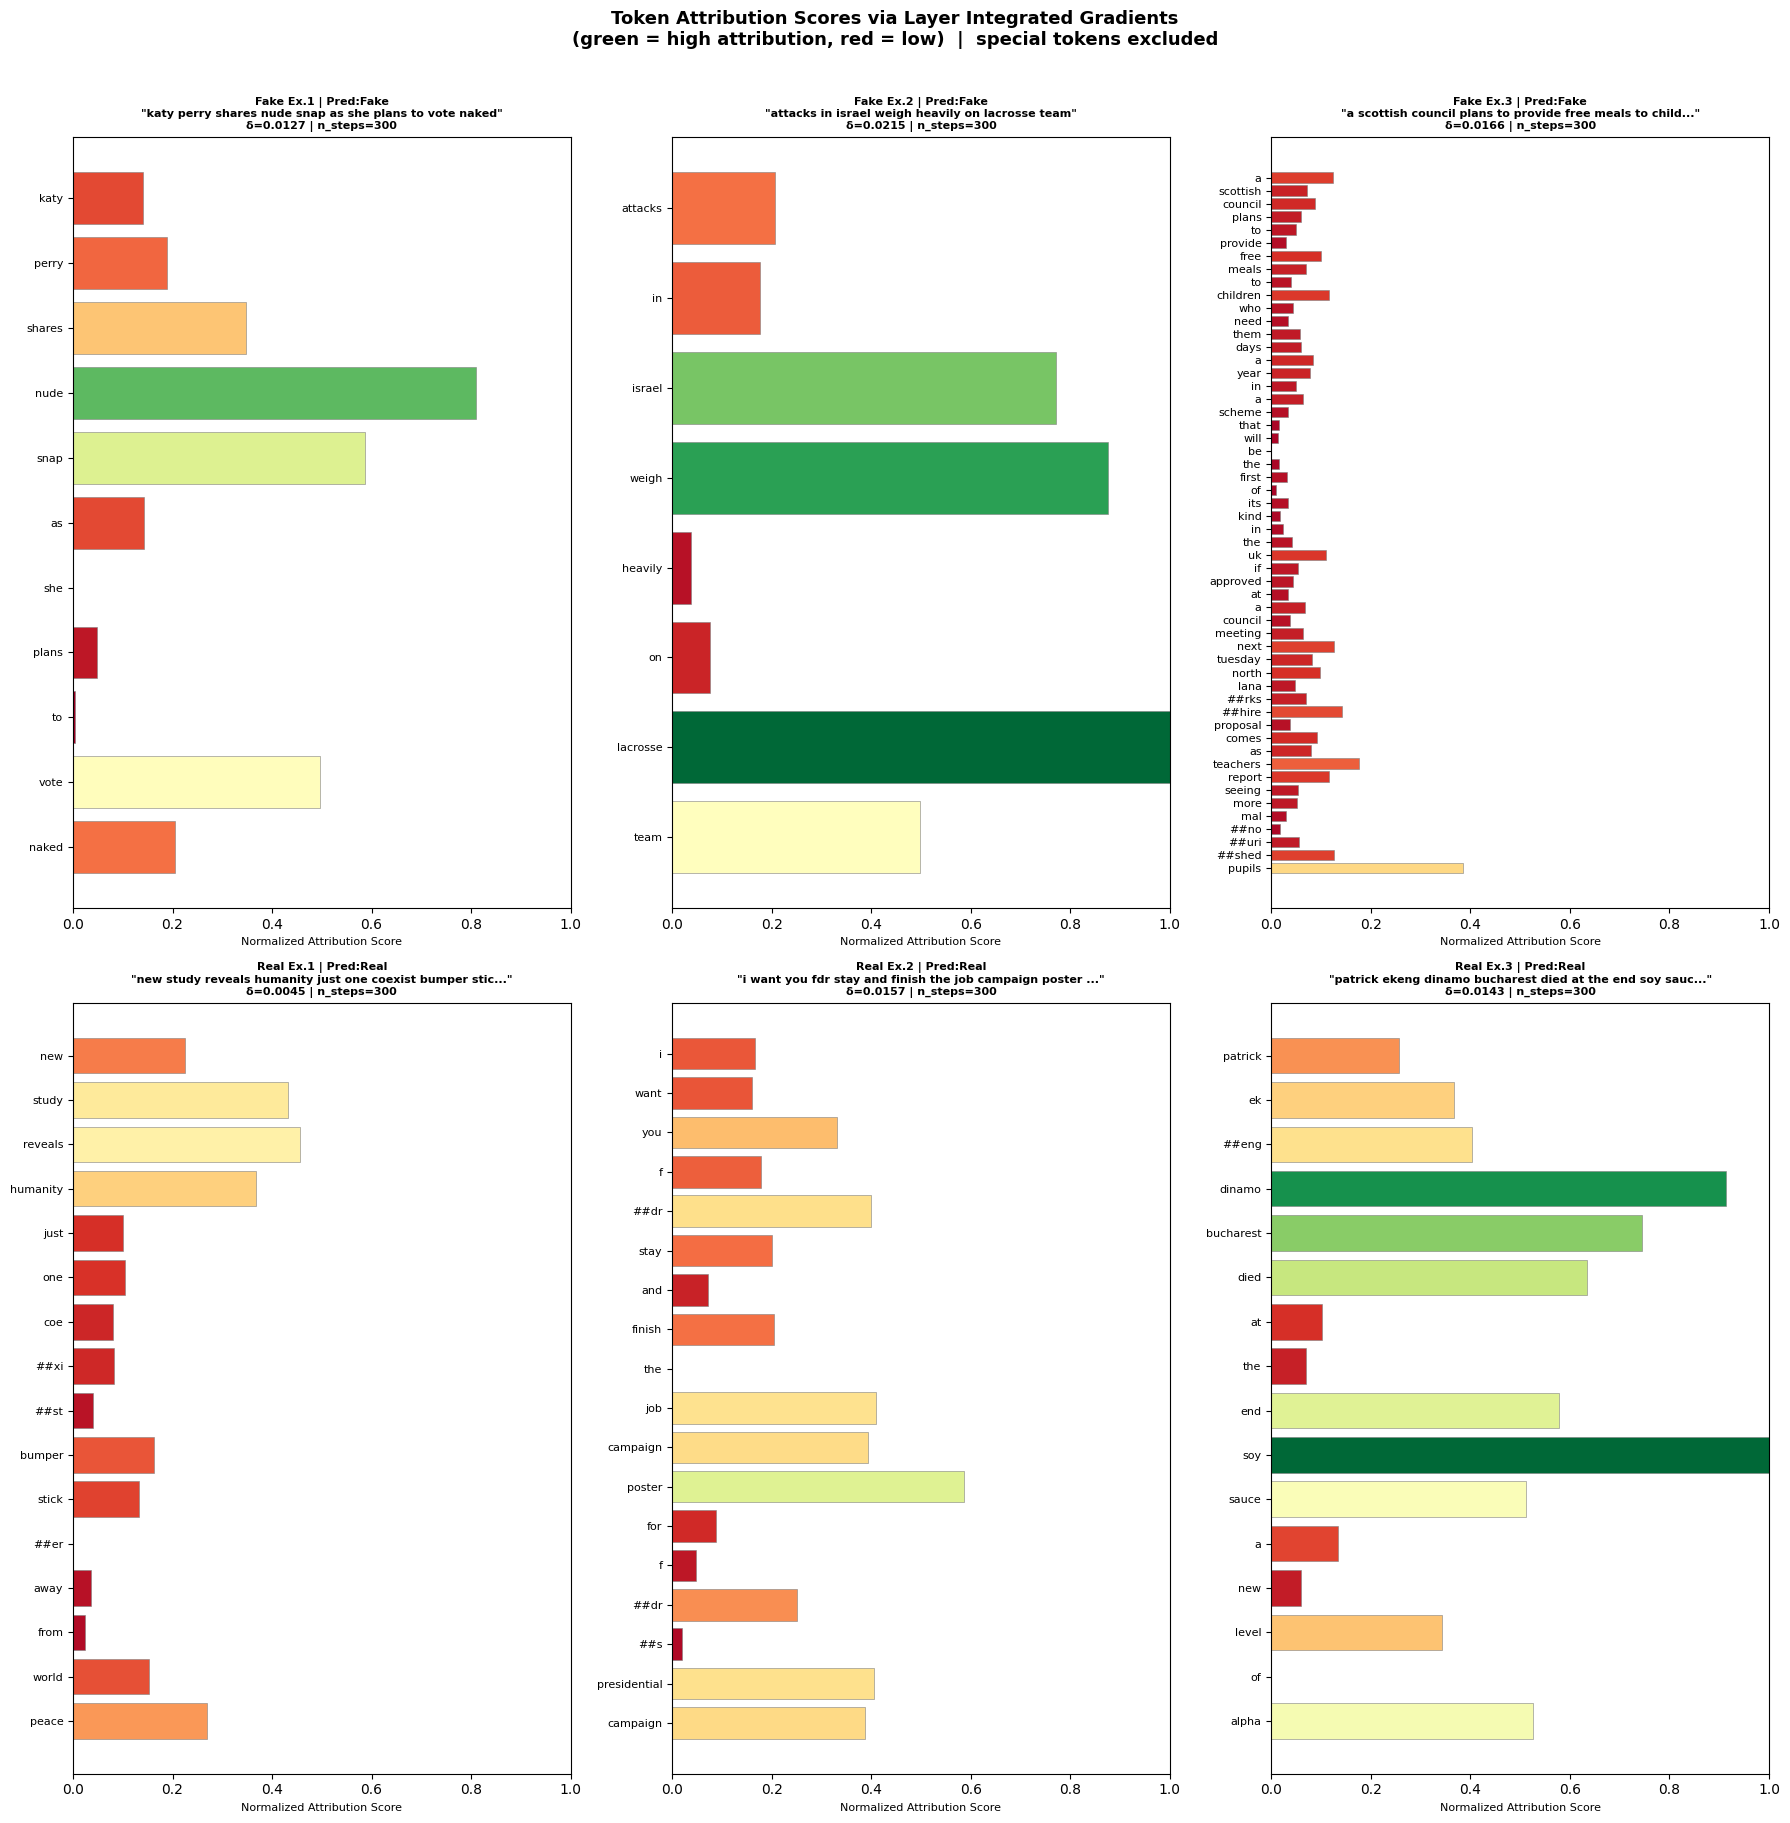

Saved: ig_attributions.png


In [33]:
# ═══════════════════════════════════════════════════════════════════════════
# 4.7  Visualise attribution scores for all 6 examples
# ═══════════════════════════════════════════════════════════════════════════
def plot_token_attributions(tokens, scores, title, ax, exclude=SPECIAL_TOKENS):
    """Horizontal bar chart of token attribution (special tokens excluded)."""
    filt_tok = [t for t in tokens if t not in exclude]
    filt_sc  = [s for t, s in zip(tokens, scores) if t not in exclude]

    if not filt_tok:
        ax.set_title(title, fontsize=8)
        return

    colors = plt.cm.RdYlGn(filt_sc)
    ax.barh(range(len(filt_tok)), filt_sc,
            color=colors, edgecolor='gray', linewidth=0.4)
    ax.set_yticks(range(len(filt_tok)))
    ax.set_yticklabels(filt_tok, fontsize=8)
    ax.set_xlabel('Normalized Attribution Score', fontsize=8)
    ax.set_title(title, fontsize=8, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.invert_yaxis()


fig, axes = plt.subplots(2, 3, figsize=(18, 18))

for row_i, (label_name, results) in enumerate(all_results.items()):
    true_cls = 1 if label_name == 'Fake' else 0
    for col_i, (text, res) in enumerate(results):
        ax      = axes[row_i][col_i]
        snippet = text[:55] + '...' if len(text) > 55 else text
        pl_title = (
            f'{label_name} Ex.{col_i+1} | '
            f'Pred:{"Fake" if res["pred_class"]==1 else "Real"}\n'
            f'"{snippet}"\n'
            f'δ={res["delta"]:.4f} | n_steps={N_STEPS}'
        )
        plot_token_attributions(res['tokens'], res['scores'], pl_title, ax)

plt.suptitle(
    'Token Attribution Scores via Layer Integrated Gradients\n'
    '(green = high attribution, red = low)  |  special tokens excluded',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('ig_attributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ig_attributions.png')

In [34]:
# ═══════════════════════════════════════════════════════════════════════════
# 4.8  Summary table: Top-5 tokens per example
# ═══════════════════════════════════════════════════════════════════════════
print('='*75)
print('  SUMMARY — Top-5 Attribution Tokens (special tokens excluded)')
print('='*75)

for label_name, results in all_results.items():
    true_cls = 1 if label_name == 'Fake' else 0
    print(f'\n▶ {label_name} examples (target class = {true_cls}):')
    print('  ' + '─'*70)
    for idx, (text, res) in enumerate(results):
        top5 = get_top_k(res['tokens'], res['scores'], k=5)
        snippet = text[:72] + '...' if len(text) > 72 else text
        top5_str = ', '.join([f'"{t}"({s:.3f})' for t, s in top5])
        print(f'  [{idx+1}] "{snippet}"')
        print(f'       delta={res["delta"]:.5f}  |  '
              f'pred={"Fake" if res["pred_class"]==1 else "Real"}')
        print(f'       Top-5: {top5_str}')
        print()

print('='*75)

  SUMMARY — Top-5 Attribution Tokens (special tokens excluded)

▶ Fake examples (target class = 1):
  ──────────────────────────────────────────────────────────────────────
  [1] "katy perry shares nude snap as she plans to vote naked"
       delta=0.01272  |  pred=Fake
       Top-5: "nude"(0.810), "snap"(0.587), "vote"(0.496), "shares"(0.348), "naked"(0.205)

  [2] "attacks in israel weigh heavily on lacrosse team"
       delta=0.02152  |  pred=Fake
       Top-5: "lacrosse"(1.000), "weigh"(0.876), "israel"(0.772), "team"(0.499), "attacks"(0.206)

  [3] "a scottish council plans to provide free meals to children who need them..."
       delta=0.01664  |  pred=Fake
       Top-5: "pupils"(0.385), "teachers"(0.176), "##hire"(0.142), "next"(0.126), "##shed"(0.126)


▶ Real examples (target class = 0):
  ──────────────────────────────────────────────────────────────────────
  [1] "new study reveals humanity just one coexist bumper sticker away from wor..."
       delta=0.00446  |  pred=Real

In [35]:
# ═══════════════════════════════════════════════════════════════════════════
# Final checklist
# ═══════════════════════════════════════════════════════════════════════════
import os
print('Generated output files:')
for fname in [
    'class_distribution.png',
    'training_curves.png',
    'confusion_matrix.png',
    'ig_attributions.png',
]:
    status = '✓' if os.path.exists(fname) else '✗ MISSING'
    print(f'  {status}  {fname}')

if os.path.isdir('fine_tuned_bert'):
    print('  ✓  fine_tuned_bert/ (saved model + tokenizer)')
else:
    print('  ✗  fine_tuned_bert/ — MISSING')

print('\n✅ All tasks complete!')

Generated output files:
  ✓  class_distribution.png
  ✓  training_curves.png
  ✓  confusion_matrix.png
  ✓  ig_attributions.png
  ✓  fine_tuned_bert/ (saved model + tokenizer)

✅ All tasks complete!
